# Metric & Normed Spaces to Banach Spaces
## A From-Scratch Journey Through the Foundations of Functional Analysis

This notebook builds the fundamental hierarchy of spaces that underpins all of functional analysis:

$$\text{Metric Space} \;\supset\; \text{Normed Space} \;\supset\; \text{Banach Space}$$

We start with the bare abstraction of *distance*, layer on *linear structure* to get norms, and then demand *completeness* to arrive at Banach spaces. Along the way we prove and visualise the theorems that make Banach spaces the workhorses of analysis: the Baire Category Theorem, the Open Mapping and Closed Graph Theorems, and the Banach Fixed-Point Theorem.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# Global constants & style
# ═══════════════════════════════════════════════════════════════════════════════

plt.rcParams.update({
    'figure.figsize' : (10, 5),
    'font.size'      : 12,
    'axes.grid'      : True,
    'grid.alpha'     : 0.3,
    'lines.linewidth': 2,
})

COLORS = {
    'blue'   : '#2196F3',
    'orange' : '#FF9800',
    'green'  : '#4CAF50',
    'red'    : '#F44336',
    'purple' : '#9C27B0',
    'teal'   : '#009688',
    'amber'  : '#FFC107',
    'indigo' : '#3F51B5',
}

FIGSIZE_WIDE   = (14, 5)
FIGSIZE_SQUARE = (7, 7)
FIGSIZE_TALL   = (10, 8)

---
## 1. Metric Spaces

### 1.1 Definition

A **metric space** is a pair $(X, d)$ where $X$ is a set and $d : X \times X \to [0, \infty)$ is a **metric** (distance function) satisfying, for all $x, y, z \in X$:

| Axiom | Statement |
|---|---|
| **Positivity** | $d(x, y) \geq 0$ with equality iff $x = y$ |
| **Symmetry** | $d(x, y) = d(y, x)$ |
| **Triangle inequality** | $d(x, z) \leq d(x, y) + d(y, z)$ |

### 1.2 Open and Closed Sets

The **open ball** of radius $r > 0$ centred at $x$ is

$$B(x, r) = \{y \in X : d(x, y) < r\}.$$

A set $U \subseteq X$ is **open** if for every $x \in U$ there exists $r > 0$ with $B(x, r) \subseteq U$. A set is **closed** if its complement is open, equivalently if it contains all its limit points.

### 1.3 Convergence and Completeness

A sequence $(x_n)$ **converges** to $x$ if $d(x_n, x) \to 0$. It is **Cauchy** if for every $\varepsilon > 0$ there exists $N$ such that $d(x_m, x_n) < \varepsilon$ for all $m, n \geq N$. A metric space is **complete** if every Cauchy sequence converges in $X$.

### 1.4 Key Examples

On $\mathbb{R}^n$ the $\ell^p$ metrics ($p \geq 1$) are

$$d_p(x, y) = \left(\sum_{i=1}^n |x_i - y_i|^p\right)^{1/p}, \qquad d_\infty(x, y) = \max_i |x_i - y_i|.$$

The **discrete metric** is $d(x,y) = \begin{cases} 0 & x=y \\ 1 & x \neq y \end{cases}$, which makes every subset both open and closed.

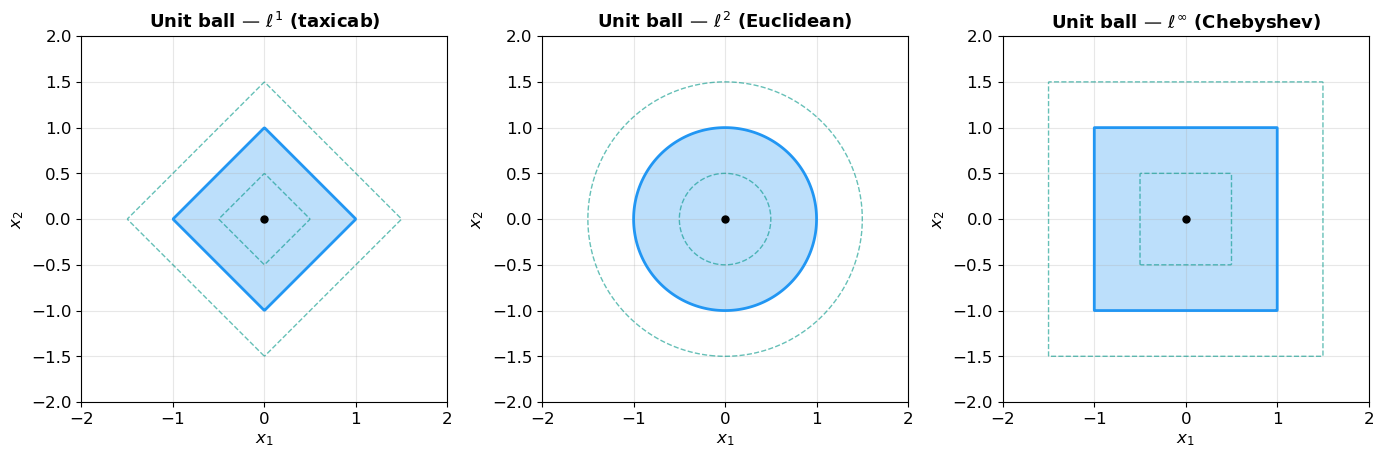

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1.5  Visualise open balls under different metrics in R^2
# ═══════════════════════════════════════════════════════════════════════════════

def lp_distance(x, y, p):
    """Compute the l^p distance between two points."""
    if p == np.inf:
        return np.max(np.abs(x - y), axis=-1)
    return np.sum(np.abs(x - y)**p, axis=-1)**(1.0 / p)


# Grid for contour plots
res = 500
t = np.linspace(-2, 2, res)
X_grid, Y_grid = np.meshgrid(t, t)
grid_pts = np.stack([X_grid, Y_grid], axis=-1)  # (res, res, 2)
origin = np.array([0.0, 0.0])

metrics = [
    (1,      '$\\ell^1$ (taxicab)'),
    (2,      '$\\ell^2$ (Euclidean)'),
    (np.inf, '$\\ell^\\infty$ (Chebyshev)'),
]

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_WIDE)

for ax, (p, label) in zip(axes, metrics):
    D = lp_distance(grid_pts, origin, p)
    # Filled contour: shade the unit ball
    ax.contourf(X_grid, Y_grid, D, levels=[0, 1], colors=[COLORS['blue']], alpha=0.30)
    # Boundary contour
    ax.contour(X_grid, Y_grid, D, levels=[1], colors=[COLORS['blue']], linewidths=2)
    # Additional level sets
    ax.contour(X_grid, Y_grid, D, levels=[0.5, 1.5], colors=[COLORS['teal']],
               linewidths=1, linestyles='dashed', alpha=0.6)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect('equal')
    ax.set_title(f'Unit ball — {label}', fontsize=13, fontweight='bold')
    ax.plot(0, 0, 'ko', ms=5)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

plt.tight_layout()
plt.show()

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1.6  Verify metric axioms numerically for random points
# ═══════════════════════════════════════════════════════════════════════════════

rng = np.random.default_rng(42)

def verify_metric_axioms(d_func, n_trials=5000, dim=3):
    """Numerically verify positivity, symmetry, and the triangle inequality."""
    x = rng.standard_normal((n_trials, dim))
    y = rng.standard_normal((n_trials, dim))
    z = rng.standard_normal((n_trials, dim))

    dxy = d_func(x, y)
    dyx = d_func(y, x)
    dxz = d_func(x, z)
    dyz = d_func(y, z)

    pos_ok   = np.all(dxy >= -1e-14)
    sym_ok   = np.allclose(dxy, dyx)
    tri_ok   = np.all(dxz <= dxy + dyz + 1e-12)

    return pos_ok, sym_ok, tri_ok


for p_val in [1, 2, 3, np.inf]:
    d = lambda a, b, p=p_val: lp_distance(a, b, p)
    pos, sym, tri = verify_metric_axioms(d)
    p_str = '\u221e' if p_val == np.inf else str(p_val)
    print(f"l^{p_str:>2s}  metric — Positivity: {pos}  Symmetry: {sym}  Triangle ineq.: {tri}")

l^ 1  metric — Positivity: True  Symmetry: True  Triangle ineq.: True
l^ 2  metric — Positivity: True  Symmetry: True  Triangle ineq.: True
l^ 3  metric — Positivity: True  Symmetry: True  Triangle ineq.: True
l^ ∞  metric — Positivity: True  Symmetry: True  Triangle ineq.: True


---
## 2. Normed Vector Spaces

### 2.1 Definition

A **normed vector space** $(V, \|\cdot\|)$ is a vector space $V$ over $\mathbb{R}$ (or $\mathbb{C}$) equipped with a function $\|\cdot\| : V \to [0,\infty)$ satisfying:

| Axiom | Statement |
|---|---|
| **Positive definiteness** | $\|x\| = 0 \iff x = 0$ |
| **Absolute homogeneity** | $\|\alpha x\| = |\alpha|\,\|x\|$ for all scalars $\alpha$ |
| **Triangle inequality** | $\|x + y\| \leq \|x\| + \|y\|$ |

Every norm induces a metric via $d(x,y) = \|x - y\|$, so every normed space is automatically a metric space. However, not every metric comes from a norm (the discrete metric does not, since it violates homogeneity).

### 2.2 The $\ell^p$ Norms

For $x \in \mathbb{R}^n$ and $1 \leq p \leq \infty$:

$$\|x\|_p = \left(\sum_{i=1}^n |x_i|^p\right)^{1/p}, \qquad \|x\|_\infty = \max_i |x_i|.$$

### 2.3 Equivalence of Norms in Finite Dimensions

**Theorem.** On $\mathbb{R}^n$, all norms are **equivalent**: for any two norms $\|\cdot\|_a$ and $\|\cdot\|_b$, there exist constants $0 < c \leq C < \infty$ such that

$$c\,\|x\|_a \leq \|x\|_b \leq C\,\|x\|_a \quad \forall\, x \in \mathbb{R}^n.$$

*Proof sketch.* The unit sphere in $\|\cdot\|_a$ is compact (Heine–Borel). The continuous function $x \mapsto \|x\|_b$ attains its min and max on this compact set, giving the constants $c$ and $C$.

**Consequence:** In $\mathbb{R}^n$ a sequence converges in one norm if and only if it converges in every norm, and a set is open in one norm if and only if it is open in every norm.

### 2.4 Non-Equivalence in Infinite Dimensions

In infinite-dimensional spaces, norms need **not** be equivalent. Consider the space $C[0,1]$ of continuous functions on $[0,1]$. Define:

$$\|f\|_\infty = \sup_{t \in [0,1]} |f(t)|, \qquad \|f\|_1 = \int_0^1 |f(t)|\, dt.$$

The sequence $f_n(t) = t^n$ satisfies $\|f_n\|_\infty = 1$ for all $n$ but $\|f_n\|_1 = 1/(n+1) \to 0$, so the two norms are **not** equivalent.

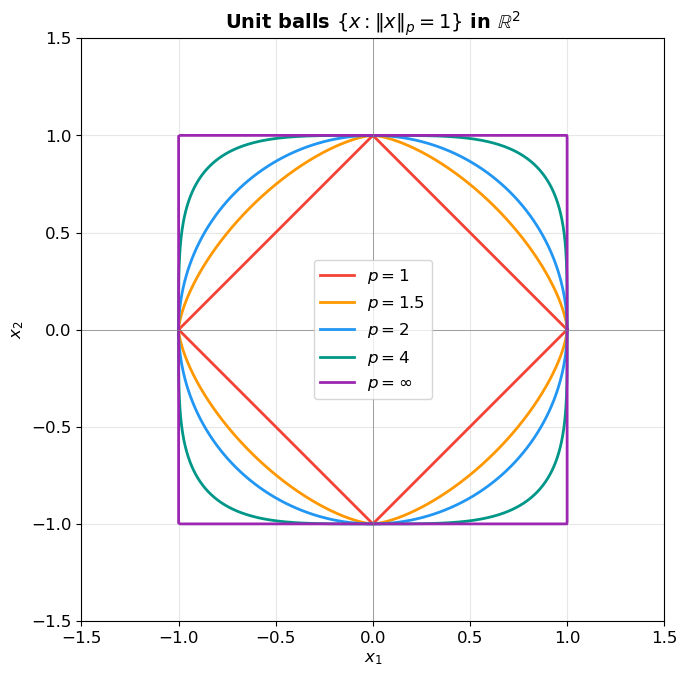

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.5  Unit balls in l^p norms — 2D comparison
# ═══════════════════════════════════════════════════════════════════════════════

theta = np.linspace(0, 2 * np.pi, 1000)

def lp_unit_ball_2d(p, n_pts=1000):
    """Return (x, y) coordinates of the l^p unit sphere in R^2."""
    t = np.linspace(0, 2 * np.pi, n_pts)
    x = np.cos(t)
    y = np.sin(t)
    pts = np.stack([x, y], axis=-1)  # (n_pts, 2)
    if p == np.inf:
        norms = np.max(np.abs(pts), axis=-1)
    else:
        norms = np.sum(np.abs(pts)**p, axis=-1)**(1.0 / p)
    # Scale each point so it lies on the l^p unit sphere
    pts_scaled = pts / norms[:, None]
    return pts_scaled[:, 0], pts_scaled[:, 1]


fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)

p_values = [
    (1,      COLORS['red'],    '$p = 1$'),
    (1.5,    COLORS['orange'], '$p = 1.5$'),
    (2,      COLORS['blue'],   '$p = 2$'),
    (4,      COLORS['teal'],   '$p = 4$'),
    (np.inf, COLORS['purple'], '$p = \\infty$'),
]

for p, color, label in p_values:
    bx, by = lp_unit_ball_2d(p)
    ax.plot(bx, by, color=color, label=label, linewidth=2)

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.set_title('Unit balls $\\{x : \\|x\\|_p = 1\\}$ in $\\mathbb{R}^2$', fontsize=14, fontweight='bold')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend(fontsize=12)
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
plt.tight_layout()
plt.show()

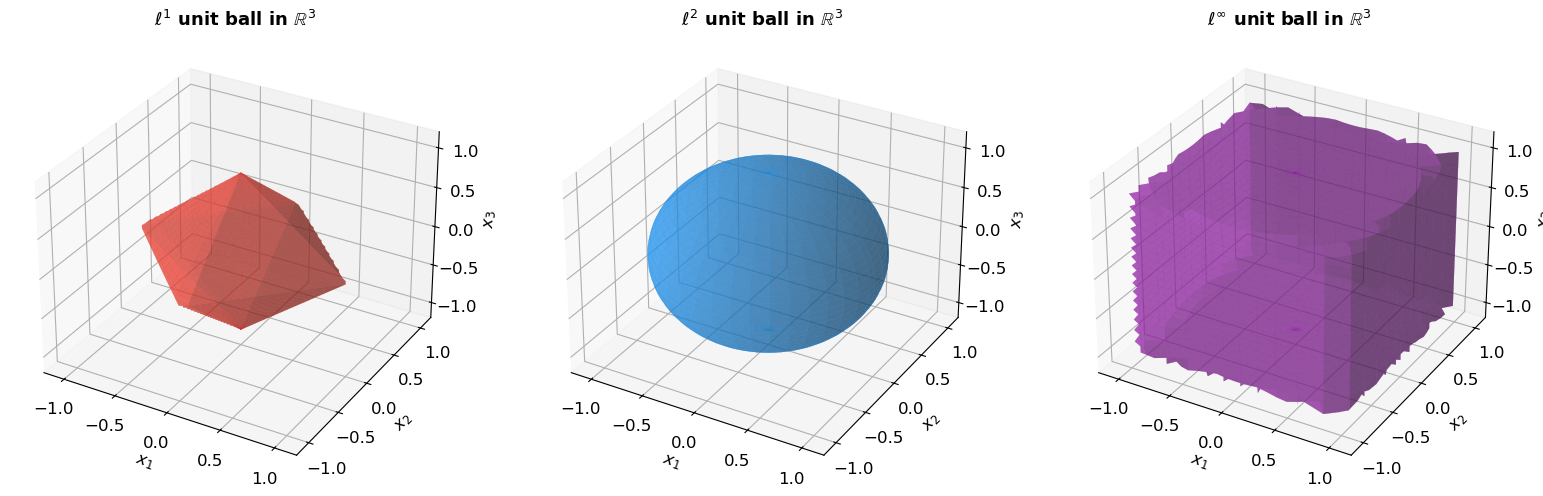

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.6  Unit balls in l^p norms — 3D comparison
# ═══════════════════════════════════════════════════════════════════════════════

def lp_unit_sphere_3d(p, n_pts=80):
    """Return (X, Y, Z) mesh for the l^p unit sphere in R^3."""
    u = np.linspace(0, np.pi, n_pts)
    v = np.linspace(0, 2 * np.pi, n_pts)
    U, V = np.meshgrid(u, v)
    # Start from the Euclidean sphere and rescale
    X = np.sin(U) * np.cos(V)
    Y = np.sin(U) * np.sin(V)
    Z = np.cos(U)
    pts = np.stack([X, Y, Z], axis=-1)
    if p == np.inf:
        norms = np.max(np.abs(pts), axis=-1)
    else:
        norms = np.sum(np.abs(pts)**p, axis=-1)**(1.0 / p)
    X_s = X / norms
    Y_s = Y / norms
    Z_s = Z / norms
    return X_s, Y_s, Z_s


fig = plt.figure(figsize=(16, 5))
p_vals_3d = [(1, '$\\ell^1$'), (2, '$\\ell^2$'), (np.inf, '$\\ell^\\infty$')]
palette_3d = [COLORS['red'], COLORS['blue'], COLORS['purple']]

for idx, ((p, label), col) in enumerate(zip(p_vals_3d, palette_3d)):
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    Xs, Ys, Zs = lp_unit_sphere_3d(p)
    ax.plot_surface(Xs, Ys, Zs, color=col, alpha=0.5, edgecolor=col, linewidth=0.1)
    ax.set_title(f'{label} unit ball in $\\mathbb{{R}}^3$', fontsize=13, fontweight='bold')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_zlabel('$x_3$')
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_zlim(-1.2, 1.2)

plt.tight_layout()
plt.show()

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.7  Norm equivalence in finite dimensions — numerical demo
# ═══════════════════════════════════════════════════════════════════════════════

# In R^n all norms are equivalent.  Find the best constants c, C such that
#   c * ||x||_a <= ||x||_b <= C * ||x||_a
# by sampling many unit vectors.

n_dim = 10
n_samples = 50000
vecs = rng.standard_normal((n_samples, n_dim))

norm_pairs = [(1, 2), (2, np.inf), (1, np.inf)]
print(f"Norm equivalence constants on R^{n_dim}  (estimated from {n_samples} random vectors)")
print("=" * 70)

for pa, pb in norm_pairs:
    na = np.linalg.norm(vecs, ord=pa, axis=1)
    nb = np.linalg.norm(vecs, ord=pb, axis=1)
    ratios = nb / na
    c_est = ratios.min()
    C_est = ratios.max()
    pa_s = '\u221e' if pa == np.inf else str(pa)
    pb_s = '\u221e' if pb == np.inf else str(pb)
    print(f"  ||x||_{pb_s} / ||x||_{pa_s}  in  [{c_est:.4f},  {C_est:.4f}]")

print("\nAll ratios are bounded above and below => norms are equivalent.")

Norm equivalence constants on R^10  (estimated from 50000 random vectors)
  ||x||_2 / ||x||_1  in  [0.3189,  0.6166]
  ||x||_∞ / ||x||_2  in  [0.3775,  0.9553]
  ||x||_∞ / ||x||_1  in  [0.1226,  0.5849]

All ratios are bounded above and below => norms are equivalent.


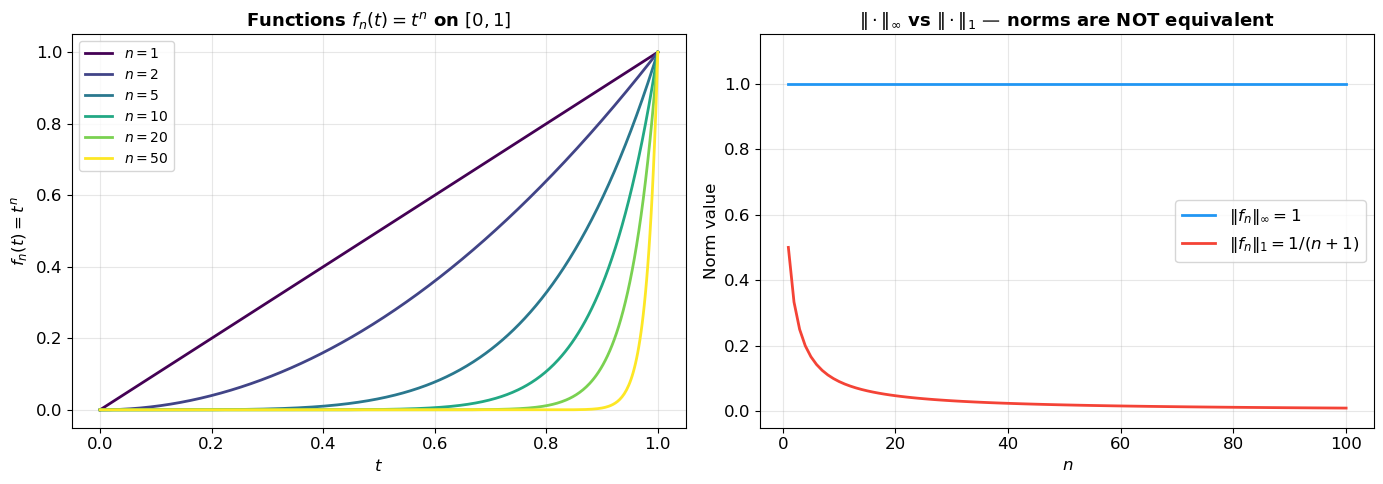

If the norms were equivalent, ||f_n||_1 -> 0 would force ||f_n||_inf -> 0.
But ||f_n||_inf = 1 for all n.  => The two norms are NOT equivalent on C[0,1].


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.8  Non-equivalence of norms in infinite dimensions
# ═══════════════════════════════════════════════════════════════════════════════

# f_n(t) = t^n on [0, 1]
# ||f_n||_inf = 1  for all n,  but  ||f_n||_1 = 1/(n+1) -> 0.

t_grid = np.linspace(0, 1, 500)
ns = [1, 2, 5, 10, 20, 50]

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Left: plot f_n(t) = t^n
cmap = plt.cm.viridis
for i, n in enumerate(ns):
    color = cmap(i / (len(ns) - 1))
    axes[0].plot(t_grid, t_grid**n, color=color, label=f'$n={n}$', linewidth=2)

axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$f_n(t) = t^n$')
axes[0].set_title('Functions $f_n(t) = t^n$ on $[0,1]$', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Right: compare the two norms as a function of n
ns_range = np.arange(1, 101)
sup_norms = np.ones_like(ns_range, dtype=float)  # always 1
l1_norms  = 1.0 / (ns_range + 1)

axes[1].plot(ns_range, sup_norms, color=COLORS['blue'], label='$\\|f_n\\|_\\infty = 1$', linewidth=2)
axes[1].plot(ns_range, l1_norms, color=COLORS['red'], label='$\\|f_n\\|_1 = 1/(n+1)$', linewidth=2)
axes[1].set_xlabel('$n$')
axes[1].set_ylabel('Norm value')
axes[1].set_title('$\\|\\cdot\\|_\\infty$ vs $\\|\\cdot\\|_1$ — norms are NOT equivalent',
                   fontsize=13, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].set_ylim(-0.05, 1.15)

plt.tight_layout()
plt.show()

print("If the norms were equivalent, ||f_n||_1 -> 0 would force ||f_n||_inf -> 0.")
print("But ||f_n||_inf = 1 for all n.  => The two norms are NOT equivalent on C[0,1].")

---
## 3. Completeness & Banach Spaces

### 3.1 Cauchy Sequences

Recall: a sequence $(x_n)$ in a metric space $(X, d)$ is **Cauchy** if

$$\forall\, \varepsilon > 0,\; \exists\, N \in \mathbb{N} : m, n \geq N \implies d(x_m, x_n) < \varepsilon.$$

Every convergent sequence is Cauchy, but the converse fails in incomplete spaces.

### 3.2 Banach Space

A **Banach space** is a normed vector space that is **complete** with respect to the metric induced by its norm.

### 3.3 Classical Examples

| Space | Norm | Complete? |
|---|---|---|
| $\mathbb{R}^n$ with $\|\cdot\|_p$ | $\ell^p$ norm | Yes — Banach space |
| $\ell^p$ (sequences with $\sum |x_i|^p < \infty$) | $\|x\|_p = (\sum |x_i|^p)^{1/p}$ | Yes — Banach space |
| $C[a,b]$ with $\|\cdot\|_\infty$ | sup-norm | Yes — Banach space |
| $C[a,b]$ with $\|\cdot\|_2$ | $L^2$-norm | **No** — not complete |
| $\mathbb{Q}$ with $|\cdot|$ | absolute value | **No** — not complete |

### 3.4 Completion

Every metric space $(X, d)$ has a **completion** $\overline{X}$: a complete metric space containing a dense isometric copy of $X$. The idea is to adjoin the "missing" limits of all Cauchy sequences. For example, the completion of $\mathbb{Q}$ is $\mathbb{R}$, and the completion of $C[a,b]$ under the $L^2$-norm is the Hilbert space $L^2[a,b]$.

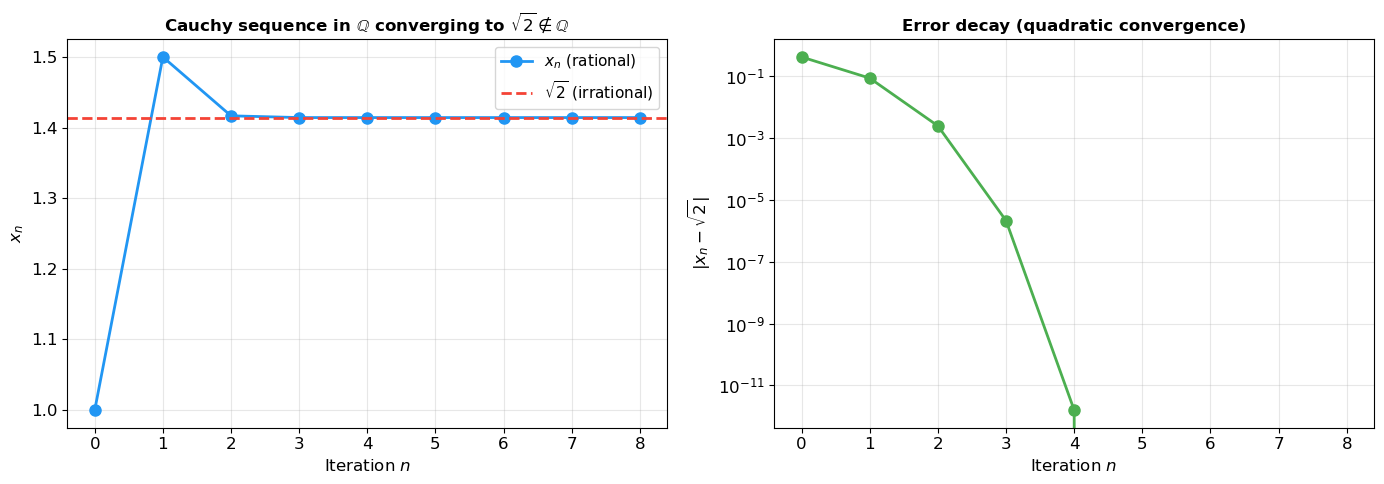

First few rational approximations:
  x_0 = 1  =  1.000000000000000
  x_1 = 3/2  =  1.500000000000000
  x_2 = 17/12  =  1.416666666666667
  x_3 = 577/408  =  1.414215686274510
  x_4 = 665857/470832  =  1.414213562374690
  x_5 = 886731088897/627013566048  =  1.414213562373095

  sqrt(2) = 1.414213562373095

All x_n are rational, but the limit sqrt(2) is irrational.
=> Q is NOT complete; this Cauchy sequence has no limit in Q.


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3.5  Cauchy sequence in Q that does NOT converge in Q
#      Successive rational approximations to sqrt(2)
# ═══════════════════════════════════════════════════════════════════════════════

# Newton's method for sqrt(2): x_{n+1} = (x_n + 2/x_n) / 2
# All iterates are rational if x_0 is rational, and the sequence converges
# to sqrt(2) which is irrational => Cauchy in Q but limit not in Q.

from fractions import Fraction

x = Fraction(1, 1)  # start rational
iterates_frac = [x]
for _ in range(8):
    x = (x + Fraction(2, 1) / x) / 2
    iterates_frac.append(x)

iterates_float = [float(f) for f in iterates_frac]
errors = [abs(v - np.sqrt(2)) for v in iterates_float]

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Left: sequence values approaching sqrt(2)
axes[0].plot(iterates_float, 'o-', color=COLORS['blue'], markersize=8, label='$x_n$ (rational)')
axes[0].axhline(np.sqrt(2), color=COLORS['red'], linestyle='--', label='$\\sqrt{2}$ (irrational)')
axes[0].set_xlabel('Iteration $n$')
axes[0].set_ylabel('$x_n$')
axes[0].set_title('Cauchy sequence in $\\mathbb{Q}$ converging to $\\sqrt{2} \\notin \\mathbb{Q}$',
                   fontsize=12, fontweight='bold')
axes[0].legend(fontsize=11)

# Right: error decay (superlinear / quadratic convergence)
axes[1].semilogy(range(len(errors)), errors, 'o-', color=COLORS['green'], markersize=8)
axes[1].set_xlabel('Iteration $n$')
axes[1].set_ylabel('$|x_n - \\sqrt{2}|$')
axes[1].set_title('Error decay (quadratic convergence)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("First few rational approximations:")
for i, f in enumerate(iterates_frac[:6]):
    print(f"  x_{i} = {f}  =  {float(f):.15f}")
print(f"\n  sqrt(2) = {np.sqrt(2):.15f}")
print("\nAll x_n are rational, but the limit sqrt(2) is irrational.")
print("=> Q is NOT complete; this Cauchy sequence has no limit in Q.")

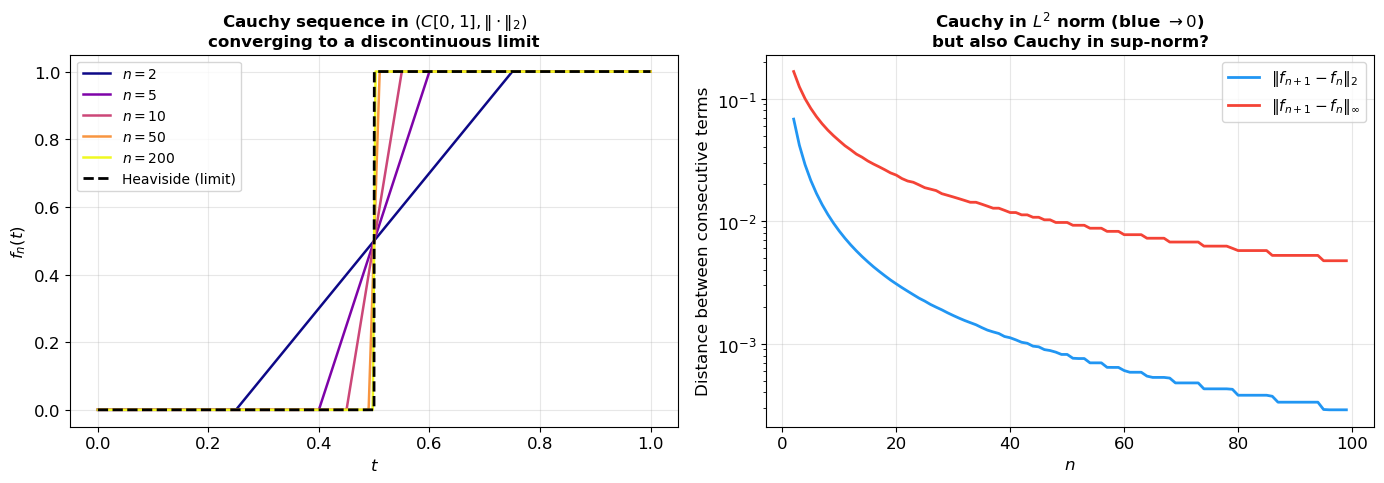

The sequence (f_n) is Cauchy in the L^2 norm.
Its L^2-limit is the Heaviside step function, which is DISCONTINUOUS.
Since the limit is not in C[0,1], the space (C[0,1], ||.||_2) is INCOMPLETE.

In contrast, (C[0,1], ||.||_inf) IS complete (a Banach space).
The same sequence is NOT Cauchy in the sup-norm (the sup-norm distances
between f_n and the Heaviside function do not go to zero).


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3.6  C[0,1] is complete under sup-norm but NOT under L^2 norm
# ═══════════════════════════════════════════════════════════════════════════════

# Construct a Cauchy sequence of continuous functions that converges
# in L^2 to a DISCONTINUOUS function (the Heaviside step).
# This limit is NOT in C[0,1], showing C[0,1] is incomplete under L^2.
#
# f_n(t) = 0 for t <= 0.5 - 1/(2n)
#         = linear ramp on [0.5 - 1/(2n), 0.5 + 1/(2n)]
#         = 1 for t >= 0.5 + 1/(2n)

def smooth_step_n(t, n):
    """Continuous approximation to Heaviside step at t=0.5."""
    half_width = 1.0 / (2 * n)
    left  = 0.5 - half_width
    right = 0.5 + half_width
    result = np.zeros_like(t, dtype=float)
    mask_mid = (t > left) & (t < right)
    result[mask_mid] = (t[mask_mid] - left) / (right - left)
    result[t >= right] = 1.0
    return result


t_fine = np.linspace(0, 1, 2000)
heaviside = np.where(t_fine >= 0.5, 1.0, 0.0)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Left: plot successive approximations
ns_approx = [2, 5, 10, 50, 200]
cmap2 = plt.cm.plasma
for i, n in enumerate(ns_approx):
    color = cmap2(i / (len(ns_approx) - 1))
    axes[0].plot(t_fine, smooth_step_n(t_fine, n), color=color, label=f'$n={n}$', linewidth=1.8)

axes[0].plot(t_fine, heaviside, 'k--', linewidth=2, label='Heaviside (limit)')
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$f_n(t)$')
axes[0].set_title('Cauchy sequence in $(C[0,1], \\|\\cdot\\|_2)$\nconverging to a discontinuous limit',
                   fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10, loc='upper left')

# Right: L^2 and sup-norm distances between successive terms
ns_seq = np.arange(2, 100)
l2_dists  = []
sup_dists = []
for n in ns_seq:
    fn  = smooth_step_n(t_fine, n)
    fn1 = smooth_step_n(t_fine, n + 1)
    diff = fn1 - fn
    dt = t_fine[1] - t_fine[0]
    l2_dists.append(np.sqrt(np.sum(diff**2) * dt))
    sup_dists.append(np.max(np.abs(diff)))

axes[1].semilogy(ns_seq, l2_dists, color=COLORS['blue'], label='$\\|f_{n+1}-f_n\\|_2$', linewidth=2)
axes[1].semilogy(ns_seq, sup_dists, color=COLORS['red'], label='$\\|f_{n+1}-f_n\\|_\\infty$', linewidth=2)
axes[1].set_xlabel('$n$')
axes[1].set_ylabel('Distance between consecutive terms')
axes[1].set_title('Cauchy in $L^2$ norm (blue $\\to 0$)\nbut also Cauchy in sup-norm?',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("The sequence (f_n) is Cauchy in the L^2 norm.")
print("Its L^2-limit is the Heaviside step function, which is DISCONTINUOUS.")
print("Since the limit is not in C[0,1], the space (C[0,1], ||.||_2) is INCOMPLETE.")
print("\nIn contrast, (C[0,1], ||.||_inf) IS complete (a Banach space).")
print("The same sequence is NOT Cauchy in the sup-norm (the sup-norm distances")
print("between f_n and the Heaviside function do not go to zero).")

---
## 4. Baire Category Theorem

### 4.1 Definitions

Let $(X, d)$ be a metric space.

- A set $A \subseteq X$ is **nowhere dense** if its closure $\overline{A}$ has empty interior: $\operatorname{int}(\overline{A}) = \emptyset$.
- A set is **meagre** (or of **first category**) if it is a countable union of nowhere dense sets.
- A set is **comeagre** (or **residual**) if its complement is meagre.

**Intuition:** A nowhere dense set is "thin" — it contains no open ball, even after filling in its limit points. A meagre set is a countable union of such thin sets and is "small" in a topological sense.

### 4.2 Baire Category Theorem

**Theorem (Baire).** Let $(X, d)$ be a **complete** metric space. Then:

1. $X$ is **not** meagre in itself: $X$ cannot be written as a countable union of nowhere dense sets.
2. Equivalently, every countable intersection of dense open sets is dense.

### 4.3 Proof Sketch

Suppose for contradiction that $X = \bigcup_{n=1}^\infty F_n$ where each $F_n$ is nowhere dense.

1. Since $F_1$ is nowhere dense, $\overline{F_1}$ has empty interior. Pick $x_1 \notin \overline{F_1}$ and an open ball $B(x_1, r_1)$ disjoint from $F_1$, with $r_1 < 1$.
2. Since $F_2$ is nowhere dense, the open set $B(x_1, r_1)$ is not contained in $\overline{F_2}$. Pick $x_2 \in B(x_1, r_1) \setminus \overline{F_2}$ and $B(x_2, r_2) \subseteq B(x_1, r_1)$ disjoint from $F_2$, with $r_2 < 1/2$.
3. Continuing inductively, we get a nested sequence of closed balls $\overline{B(x_n, r_n)}$ with $r_n \to 0$, each disjoint from $F_n$.
4. By completeness, $\bigcap_n \overline{B(x_n, r_n)} \neq \emptyset$. Let $x^*$ be in this intersection.
5. Then $x^* \notin F_n$ for any $n$, contradicting $X = \bigcup_n F_n$. $\square$

### 4.4 Consequences

1. **$\mathbb{R}$ is uncountable.** If $\mathbb{R}$ were countable, we could write $\mathbb{R} = \bigcup_n \{r_n\}$. Each singleton $\{r_n\}$ is nowhere dense. But $\mathbb{R}$ is complete, contradicting Baire.

2. **Nowhere-differentiable functions are "generic".** In the Banach space $(C[0,1], \|\cdot\|_\infty)$, the set of functions that are differentiable at even one point is meagre. The "typical" continuous function is nowhere differentiable.

3. The **Uniform Boundedness Principle** (Banach–Steinhaus Theorem) is a direct consequence of Baire.

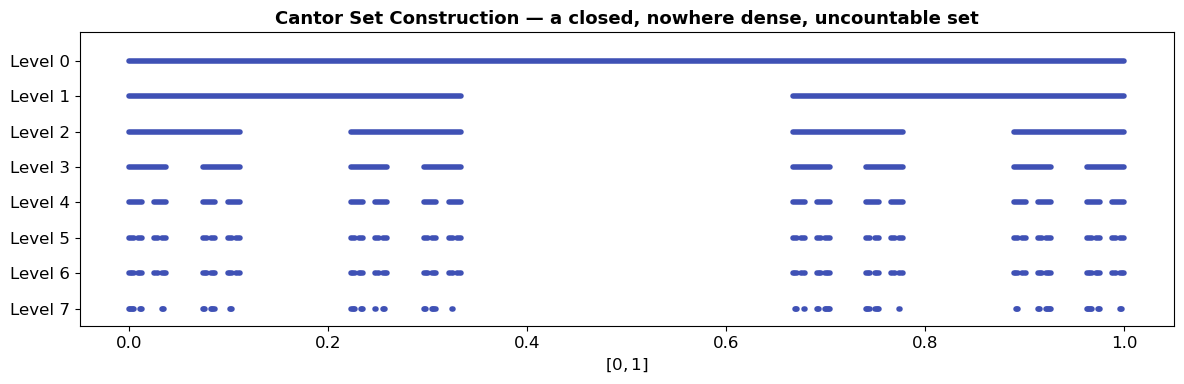

The Cantor set is nowhere dense: its closure (itself, since it is closed)
contains no open interval.

By the Baire Category Theorem, [0,1] (complete metric space) cannot be
written as a countable union of nowhere dense sets like the Cantor set.
Even countably many 'copies' of C would leave most of [0,1] uncovered.


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4.5  Visualising nowhere dense sets and the Baire Category Theorem
# ═══════════════════════════════════════════════════════════════════════════════

# The standard Cantor set is closed, nowhere dense, and uncountable.
# It shows that "nowhere dense" does not mean "small" in every sense.
# But a COUNTABLE union of such sets cannot cover [0,1] (Baire!).

def cantor_set_intervals(n_levels):
    """Return the intervals remaining after n levels of the Cantor construction."""
    intervals = [(0.0, 1.0)]
    for _ in range(n_levels):
        new_intervals = []
        for a, b in intervals:
            third = (b - a) / 3
            new_intervals.append((a, a + third))
            new_intervals.append((b - third, b))
        intervals = new_intervals
    return intervals


fig, ax = plt.subplots(figsize=(12, 4))

n_levels = 7
for level in range(n_levels + 1):
    intervals = cantor_set_intervals(level)
    y = n_levels - level
    for a, b in intervals:
        ax.plot([a, b], [y, y], color=COLORS['indigo'], linewidth=4, solid_capstyle='round')

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.5, n_levels + 0.8)
ax.set_yticks(range(n_levels + 1))
ax.set_yticklabels([f'Level {n_levels - i}' for i in range(n_levels + 1)])
ax.set_xlabel('$[0, 1]$')
ax.set_title('Cantor Set Construction — a closed, nowhere dense, uncountable set',
             fontsize=13, fontweight='bold')
ax.grid(False)

plt.tight_layout()
plt.show()

print("The Cantor set is nowhere dense: its closure (itself, since it is closed)")
print("contains no open interval.")
print("\nBy the Baire Category Theorem, [0,1] (complete metric space) cannot be")
print("written as a countable union of nowhere dense sets like the Cantor set.")
print("Even countably many 'copies' of C would leave most of [0,1] uncovered.")

---
## 5. Open Mapping & Closed Graph Theorems

These are two of the "Big Three" theorems of Banach space theory (along with the Uniform Boundedness Principle). They crucially depend on completeness via the Baire Category Theorem.

### 5.1 Open Mapping Theorem (Banach–Schauder)

**Theorem.** Let $X$ and $Y$ be Banach spaces and $T : X \to Y$ a **bounded linear surjection**. Then $T$ is an **open map**: it maps open sets to open sets.

**Corollary (Bounded Inverse Theorem).** If $T : X \to Y$ is a bounded linear bijection between Banach spaces, then $T^{-1}$ is also bounded.

This is remarkable: in general topological spaces, a continuous bijection need not have a continuous inverse. Completeness forces it.

### 5.2 Proof Sketch (Open Mapping Theorem)

1. Since $T$ is surjective, $Y = \bigcup_{n=1}^\infty T(B_X(0, n))$, where $B_X(0,n)$ is the open ball of radius $n$ in $X$.
2. By the **Baire Category Theorem** (since $Y$ is complete), some $\overline{T(B_X(0, n))}$ has non-empty interior.
3. By linearity and scaling, $\overline{T(B_X(0, 1))}$ contains a ball $B_Y(0, \delta)$ for some $\delta > 0$.
4. An approximation argument (using completeness of $X$) then "upgrades" the closure to show $T(B_X(0, 1)) \supseteq B_Y(0, \delta')$ for some $\delta' > 0$.
5. This means $T$ maps the open unit ball to a set containing an open ball, hence $T$ is open. $\square$

### 5.3 Closed Graph Theorem

**Theorem.** Let $X$ and $Y$ be Banach spaces and $T : X \to Y$ a **linear** map. If the graph

$$\operatorname{Graph}(T) = \{(x, Tx) : x \in X\} \subseteq X \times Y$$

is **closed** in $X \times Y$, then $T$ is **bounded** (i.e., continuous).

This is extremely useful in practice: to show a linear map is bounded, it suffices to show that $x_n \to x$ and $Tx_n \to y$ imply $y = Tx$.

### 5.4 Relationship

The Closed Graph Theorem follows from the Open Mapping Theorem:
- If $\operatorname{Graph}(T)$ is closed, it is a Banach space (closed subspace of $X \times Y$).
- The projection $\pi_1 : \operatorname{Graph}(T) \to X$ given by $(x, Tx) \mapsto x$ is a bounded linear bijection.
- By the Bounded Inverse Theorem, $\pi_1^{-1}$ is bounded.
- Then $T = \pi_2 \circ \pi_1^{-1}$ is bounded (composition of bounded maps).

T : R^3 -> R^2, represented by A = 
[[2.  1.  0.5]
 [0.  1.5 1. ]]

Rank of A = 2  (full row rank => surjective)


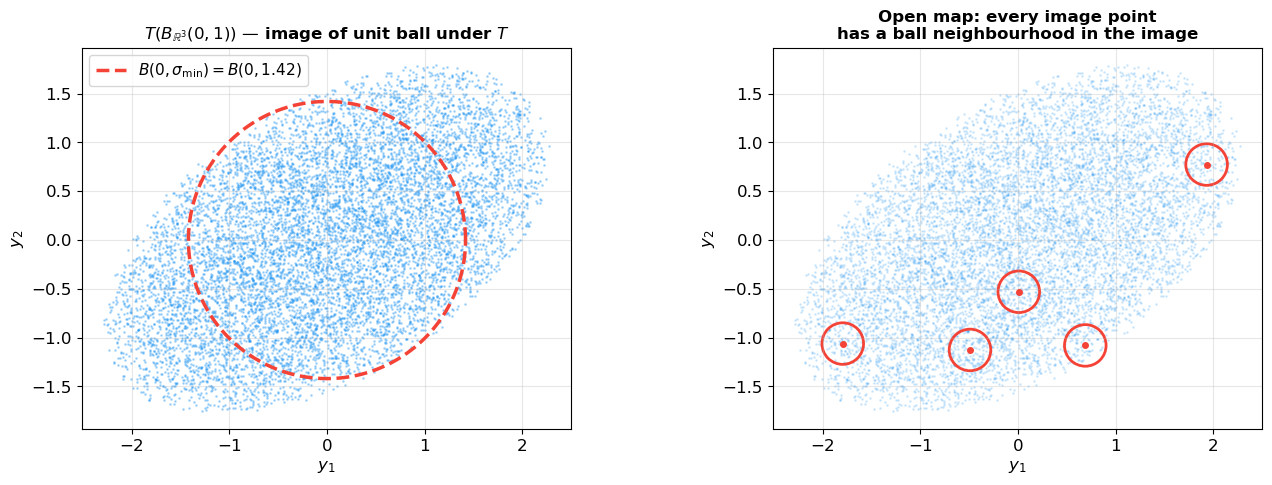


Singular values of A: [2.546776   1.41913073]
sigma_min = 1.4191

The Open Mapping Theorem guarantees that T(B(0,1)) contains B(0, sigma_min).
Since T is a bounded surjection between Banach spaces, it maps open sets to open sets.


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5.5  Concrete example: Open Mapping Theorem in finite dimensions
# ═══════════════════════════════════════════════════════════════════════════════

# T : R^3 -> R^2 defined by the matrix A (a surjection).
# The OMT guarantees T maps open sets to open sets.
# We visualize: the image of the unit ball in R^3 under T contains an open ball in R^2.

A = np.array([[2.0, 1.0, 0.5],
              [0.0, 1.5, 1.0]])

print(f"T : R^3 -> R^2, represented by A = ")
print(A)
print(f"\nRank of A = {np.linalg.matrix_rank(A)}  (full row rank => surjective)")

# Sample many points from the unit ball in R^3
n_pts = 10000
pts_3d = rng.standard_normal((n_pts, 3))
norms_3d = np.linalg.norm(pts_3d, axis=1, keepdims=True)
# Scale to be uniformly distributed in the unit ball
radii = rng.uniform(0, 1, (n_pts, 1))**(1.0 / 3)
pts_3d = pts_3d / norms_3d * radii

# Apply T
pts_2d = (A @ pts_3d.T).T  # (n_pts, 2)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Left: image of the unit ball
axes[0].scatter(pts_2d[:, 0], pts_2d[:, 1], s=1, alpha=0.3, color=COLORS['blue'])
axes[0].set_aspect('equal')
axes[0].set_title('$T(B_{\\mathbb{R}^3}(0,1))$ — image of unit ball under $T$',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('$y_1$')
axes[0].set_ylabel('$y_2$')

# Find the largest inscribed ball (approximate)
# The image is an ellipse; find the minimum singular value of A,
# which gives the radius of the largest ball contained in T(B(0,1)).
_, sigmas, _ = np.linalg.svd(A)
sigma_min = sigmas[-1]  # This is for R^3 -> R^2; we want min of the 2 singular values
sigma_min_2 = sigmas.min()

# The minimum singular value of A gives the largest r such that B(0,r) subset T(B(0,1))
# For a surjective T: R^n -> R^m, the image of B(0,1) contains B(0, sigma_min)
theta_circ = np.linspace(0, 2 * np.pi, 200)
axes[0].plot(sigma_min_2 * np.cos(theta_circ), sigma_min_2 * np.sin(theta_circ),
             color=COLORS['red'], linewidth=2.5, linestyle='--',
             label=f'$B(0, \\sigma_{{\\min}}) = B(0, {sigma_min_2:.2f})$')
axes[0].legend(fontsize=11)

# Right: show that the image is open by checking it contains a ball
# around every interior point (sample a few)
axes[1].scatter(pts_2d[:, 0], pts_2d[:, 1], s=1, alpha=0.15, color=COLORS['blue'])
test_points = pts_2d[rng.choice(n_pts, 5, replace=False)]
for tp in test_points:
    # Each point in the interior should have a ball around it inside the image
    circle = plt.Circle(tp, sigma_min_2 * 0.15, fill=False, color=COLORS['red'],
                        linewidth=2, linestyle='-')
    axes[1].add_patch(circle)
    axes[1].plot(tp[0], tp[1], 'o', color=COLORS['red'], ms=4)

axes[1].set_aspect('equal')
axes[1].set_title('Open map: every image point\nhas a ball neighbourhood in the image',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('$y_1$')
axes[1].set_ylabel('$y_2$')

plt.tight_layout()
plt.show()

print(f"\nSingular values of A: {sigmas}")
print(f"sigma_min = {sigma_min_2:.4f}")
print(f"\nThe Open Mapping Theorem guarantees that T(B(0,1)) contains B(0, sigma_min).")
print(f"Since T is a bounded surjection between Banach spaces, it maps open sets to open sets.")

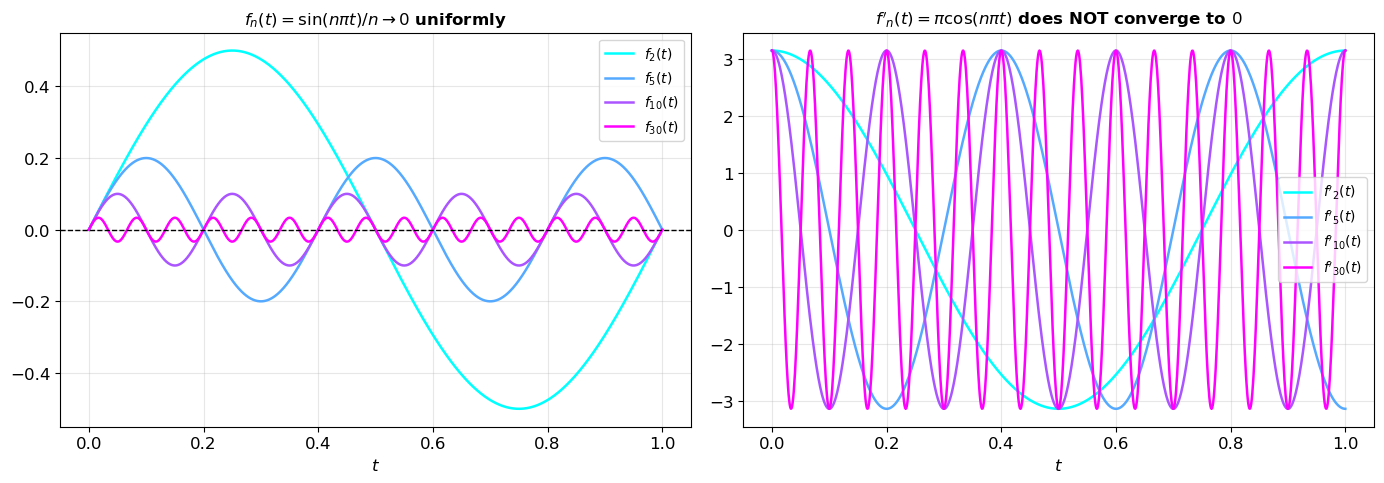

D = differentiation operator from (C^1[0,1], ||.||_inf) to (C[0,1], ||.||_inf).

f_n -> 0 in sup-norm, but Df_n = f'_n does not converge to D(0) = 0.
=> The graph of D is NOT closed in (C[0,1]) x (C[0,1]).
=> By the Closed Graph Theorem, D must be unbounded (which it is!).

This illustrates WHY completeness matters: the CGT gives us a powerful
tool to prove operators are bounded, or to detect unbounded operators.


In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5.6  Closed Graph Theorem — illustrative example
# ═══════════════════════════════════════════════════════════════════════════════

# Consider the differentiation operator D : C^1[0,1] -> C[0,1], Df = f'.
# D is linear.  Its graph is {(f, f') : f in C^1[0,1]}.
#
# If we give C^1[0,1] the sup-norm (not the C^1-norm), then D is UNBOUNDED.
# The Closed Graph Theorem tells us the graph must NOT be closed.
# Indeed: f_n(t) = sin(n*t)/n  ->  0  in sup-norm,
# but  f_n'(t) = cos(n*t) does NOT converge to 0 = (D*0)(t).
# So (f_n, Df_n) -> (0, ???) where the second component doesn't converge to D(0)=0.
# This witnesses the non-closedness of the graph.

t_plot = np.linspace(0, 1, 1000)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

ns_demo = [2, 5, 10, 30]
cmap3 = plt.cm.cool

for i, n in enumerate(ns_demo):
    color = cmap3(i / (len(ns_demo) - 1))
    fn  = np.sin(n * np.pi * t_plot) / n
    dfn = np.pi * np.cos(n * np.pi * t_plot)  # derivative
    axes[0].plot(t_plot, fn, color=color, label=f'$f_{{{n}}}(t)$', linewidth=1.8)
    axes[1].plot(t_plot, dfn, color=color, label=f"$f'_{{{n}}}(t)$", linewidth=1.8)

axes[0].axhline(0, color='k', linestyle='--', linewidth=1)
axes[0].set_title('$f_n(t) = \\sin(n\\pi t)/n \\to 0$ uniformly',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('$t$')
axes[0].legend(fontsize=10)

axes[1].set_title("$f'_n(t) = \\pi\\cos(n\\pi t)$ does NOT converge to $0$",
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('$t$')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print("D = differentiation operator from (C^1[0,1], ||.||_inf) to (C[0,1], ||.||_inf).")
print("\nf_n -> 0 in sup-norm, but Df_n = f'_n does not converge to D(0) = 0.")
print("=> The graph of D is NOT closed in (C[0,1]) x (C[0,1]).")
print("=> By the Closed Graph Theorem, D must be unbounded (which it is!).")
print("\nThis illustrates WHY completeness matters: the CGT gives us a powerful")
print("tool to prove operators are bounded, or to detect unbounded operators.")

---
## 6. Banach Fixed-Point Theorem

### 6.1 Contraction Mappings

Let $(X, d)$ be a metric space. A map $T : X \to X$ is a **contraction** if there exists $0 \leq q < 1$ such that

$$d(Tx, Ty) \leq q \cdot d(x, y) \quad \forall\, x, y \in X.$$

The constant $q$ is called the **contraction factor** (or Lipschitz constant).

### 6.2 Banach Fixed-Point Theorem (Contraction Mapping Principle)

**Theorem.** Let $(X, d)$ be a **complete** metric space and $T : X \to X$ a contraction with factor $q$. Then:

1. $T$ has a **unique fixed point** $x^* \in X$: $T(x^*) = x^*$.
2. For any starting point $x_0 \in X$, the iterates $x_{n+1} = T(x_n)$ converge to $x^*$.
3. **A priori error bound:** $d(x_n, x^*) \leq \dfrac{q^n}{1 - q}\, d(x_0, x_1)$.
4. **A posteriori error bound:** $d(x_n, x^*) \leq \dfrac{q}{1 - q}\, d(x_{n-1}, x_n)$.

### 6.3 Proof

1. **Cauchy sequence.** By contraction, $d(x_{n+1}, x_n) \leq q^n\, d(x_1, x_0)$. For $m > n$:
$$d(x_m, x_n) \leq \sum_{k=n}^{m-1} d(x_{k+1}, x_k) \leq d(x_1, x_0) \sum_{k=n}^{m-1} q^k \leq \frac{q^n}{1-q}\, d(x_1, x_0) \to 0.$$
So $(x_n)$ is Cauchy.

2. **Convergence.** By completeness, $x_n \to x^*$ for some $x^* \in X$.

3. **Fixed point.** $T$ is continuous (Lipschitz), so $T(x^*) = T(\lim x_n) = \lim T(x_n) = \lim x_{n+1} = x^*$.

4. **Uniqueness.** If $T(y^*) = y^*$ also, then $d(x^*, y^*) = d(Tx^*, Ty^*) \leq q\, d(x^*, y^*)$, which forces $d(x^*, y^*) = 0$ since $q < 1$. $\square$

### 6.4 Convergence Rate

The error decreases **geometrically**: $d(x_n, x^*) = O(q^n)$. Smaller contraction factors give faster convergence.

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# 6.5  Banach fixed-point iteration: solve cos(x) = x
# ═══════════════════════════════════════════════════════════════════════════════

# T(x) = cos(x) is a contraction on [0, 1] because
# |T'(x)| = |sin(x)| <= sin(1) ~ 0.841 < 1  on [0, 1].

T_func = np.cos
q_est = np.sin(1.0)  # Lipschitz constant on [0, 1]

x0 = 0.0
iterates = [x0]
for _ in range(30):
    x0 = T_func(x0)
    iterates.append(x0)

iterates = np.array(iterates)
x_star = iterates[-1]  # converged value

print(f"Fixed point x* = {x_star:.15f}")
print(f"cos(x*)        = {np.cos(x_star):.15f}")
print(f"Contraction factor q ~ sin(1) = {q_est:.6f}")

Fixed point x* = 0.739082298522402
cos(x*)        = 0.739087042695332
Contraction factor q ~ sin(1) = 0.841471


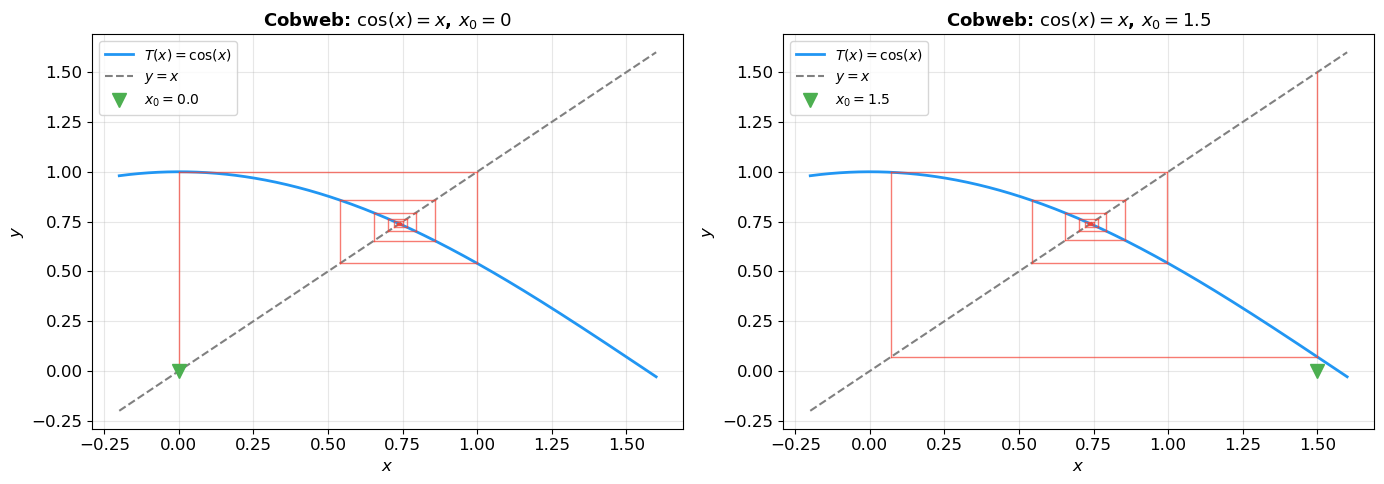

Regardless of the starting point, the iterates spiral inward to the unique fixed point.
x* = 0.7390822985  (the Dottie number)


In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# 6.6  Cobweb plot for fixed-point iteration  cos(x) = x
# ═══════════════════════════════════════════════════════════════════════════════

def cobweb_plot(ax, f, x0, n_iters, x_range, f_label='$T(x)$', title='Cobweb plot'):
    """Draw a cobweb diagram for the fixed-point iteration x_{n+1} = f(x_n)."""
    xs = np.linspace(x_range[0], x_range[1], 500)
    ax.plot(xs, f(xs), color=COLORS['blue'], linewidth=2, label=f_label)
    ax.plot(xs, xs, color='grey', linewidth=1.5, linestyle='--', label='$y = x$')

    # Cobweb lines
    x = x0
    for i in range(n_iters):
        y = f(x)
        # vertical line from (x, x) to (x, f(x))
        ax.plot([x, x], [x, y], color=COLORS['red'], linewidth=1, alpha=0.7)
        # horizontal line from (x, f(x)) to (f(x), f(x))
        ax.plot([x, y], [y, y], color=COLORS['red'], linewidth=1, alpha=0.7)
        x = y

    ax.plot(x0, 0, 'v', color=COLORS['green'], ms=10, label=f'$x_0 = {x0}$')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')


fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Left: cobweb for cos(x) = x, starting from x0 = 0
cobweb_plot(axes[0], np.cos, 0.0, 20, (-0.2, 1.6),
            f_label='$T(x) = \\cos(x)$',
            title='Cobweb: $\\cos(x) = x$, $x_0 = 0$')

# Right: cobweb for cos(x) = x, starting from x0 = 1.5
cobweb_plot(axes[1], np.cos, 1.5, 20, (-0.2, 1.6),
            f_label='$T(x) = \\cos(x)$',
            title='Cobweb: $\\cos(x) = x$, $x_0 = 1.5$')

plt.tight_layout()
plt.show()

print("Regardless of the starting point, the iterates spiral inward to the unique fixed point.")
print(f"x* = {x_star:.10f}  (the Dottie number)")

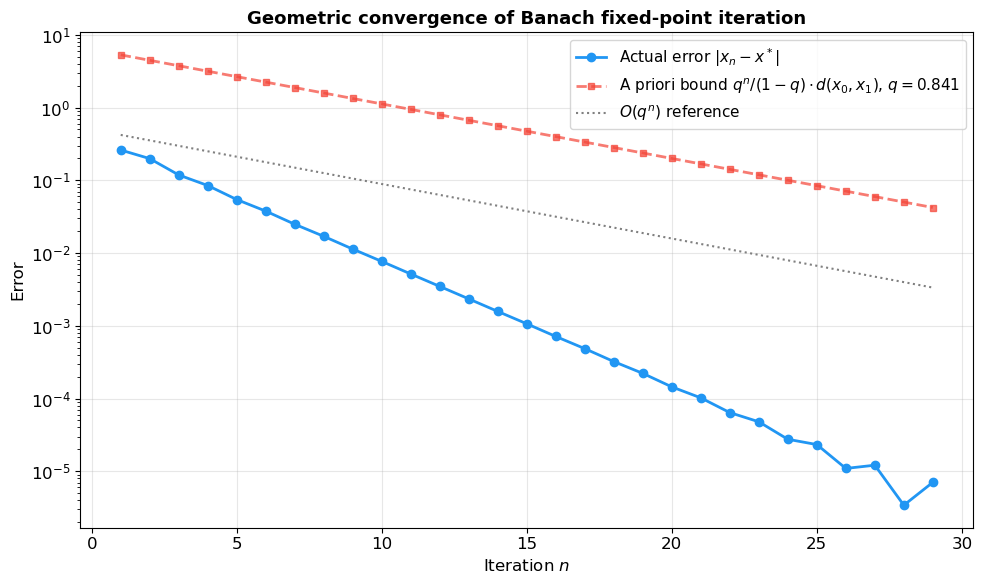

Contraction factor q = sin(1) = 0.841471
After n iterations, error is bounded by O(0.841^n).
Actual convergence is geometric, as predicted by the theorem.


In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# 6.7  Convergence rate and error bounds
# ═══════════════════════════════════════════════════════════════════════════════

errors = np.abs(iterates[:-1] - x_star)  # |x_n - x*|
n_vals = np.arange(len(errors))

# A priori bound:  |x_n - x*| <= q^n / (1-q) * |x_1 - x_0|
d01 = np.abs(iterates[1] - iterates[0])
a_priori_bound = (q_est**n_vals) / (1 - q_est) * d01

fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogy(n_vals[1:], errors[1:], 'o-', color=COLORS['blue'], markersize=6,
            label='Actual error $|x_n - x^*|$')
ax.semilogy(n_vals[1:], a_priori_bound[1:], 's--', color=COLORS['red'], markersize=5,
            alpha=0.7, label=f'A priori bound $q^n/(1-q) \\cdot d(x_0,x_1)$, $q={q_est:.3f}$')

# Reference geometric decay
ax.semilogy(n_vals[1:], 0.5 * q_est**n_vals[1:], ':', color='grey', linewidth=1.5,
            label=f'$O(q^n)$ reference')

ax.set_xlabel('Iteration $n$')
ax.set_ylabel('Error')
ax.set_title('Geometric convergence of Banach fixed-point iteration',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"Contraction factor q = sin(1) = {q_est:.6f}")
print(f"After n iterations, error is bounded by O({q_est:.3f}^n).")
print(f"Actual convergence is geometric, as predicted by the theorem.")

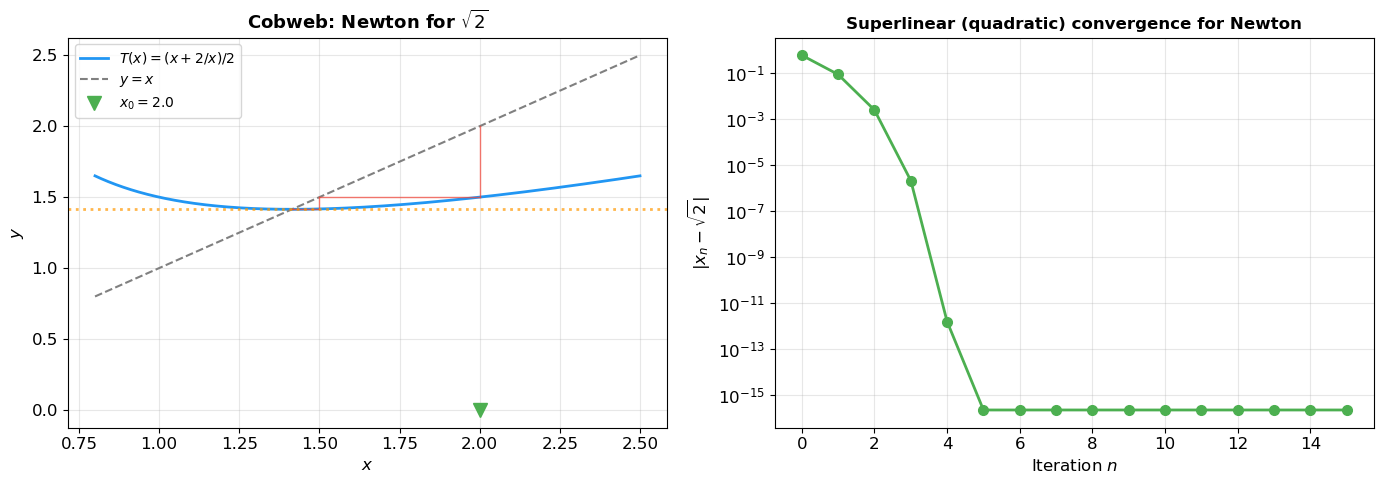

Newton's method is also a contraction mapping iteration.
The quadratic convergence (error squares each step) is visible in the log plot.
After 6 iterations: error = 2.22e-16


In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# 6.8  Banach fixed-point for another equation: x = (x + 2/x)/2 (sqrt(2))
# ═══════════════════════════════════════════════════════════════════════════════

# This is Newton's method for sqrt(2), i.e., T(x) = (x + 2/x)/2.
# On [1, 2]: T'(x) = (1 - 2/x^2)/2, |T'(x)| <= |1 - 2|/2 = 0.5 at x=1 (worst).
# Actually T'(x) = 1/2 - 1/x^2, |T'(x)| <= 1/2 on [1,2].
# This is a contraction => converges to sqrt(2).

T_sqrt2 = lambda x: 0.5 * (x + 2.0 / x)

x0_s = 2.0
iters_sqrt2 = [x0_s]
for _ in range(15):
    x0_s = T_sqrt2(x0_s)
    iters_sqrt2.append(x0_s)

iters_sqrt2 = np.array(iters_sqrt2)
errs_sqrt2 = np.abs(iters_sqrt2 - np.sqrt(2))

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

cobweb_plot(axes[0], T_sqrt2, 2.0, 8, (0.8, 2.5),
            f_label='$T(x) = (x + 2/x)/2$',
            title='Cobweb: Newton for $\\sqrt{2}$')
axes[0].axhline(np.sqrt(2), color=COLORS['orange'], linestyle=':', alpha=0.7)

axes[1].semilogy(range(len(errs_sqrt2)), errs_sqrt2 + 1e-17, 'o-',
                 color=COLORS['green'], markersize=7)
axes[1].set_xlabel('Iteration $n$')
axes[1].set_ylabel('$|x_n - \\sqrt{2}|$')
axes[1].set_title('Superlinear (quadratic) convergence for Newton',
                   fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Newton's method is also a contraction mapping iteration.")
print("The quadratic convergence (error squares each step) is visible in the log plot.")
print(f"After 6 iterations: error = {errs_sqrt2[6]:.2e}")

### 6.9 Picard Iteration for ODE Existence & Uniqueness

The Banach Fixed-Point Theorem is the engine behind the **Picard–Lindelof Theorem**, which guarantees existence and uniqueness of solutions to initial value problems.

**Setup.** Consider the IVP:

$$y'(t) = f(t, y(t)), \qquad y(t_0) = y_0.$$

This is equivalent to the integral equation

$$y(t) = y_0 + \int_{t_0}^t f(s, y(s))\, ds.$$

Define the **Picard operator** $\mathcal{T}$ on continuous functions:

$$(\mathcal{T}\varphi)(t) = y_0 + \int_{t_0}^t f(s, \varphi(s))\, ds.$$

If $f$ is Lipschitz in $y$, then $\mathcal{T}$ is a contraction on a suitable function space (with an appropriate weighted sup-norm), and the Banach Fixed-Point Theorem gives a unique fixed point $\varphi^* = \mathcal{T}\varphi^*$, which is the unique solution of the ODE.

**Picard iterates:**

$$\varphi_0(t) = y_0, \qquad \varphi_{n+1}(t) = y_0 + \int_{t_0}^t f(s, \varphi_n(s))\, ds.$$

These converge uniformly to the exact solution.

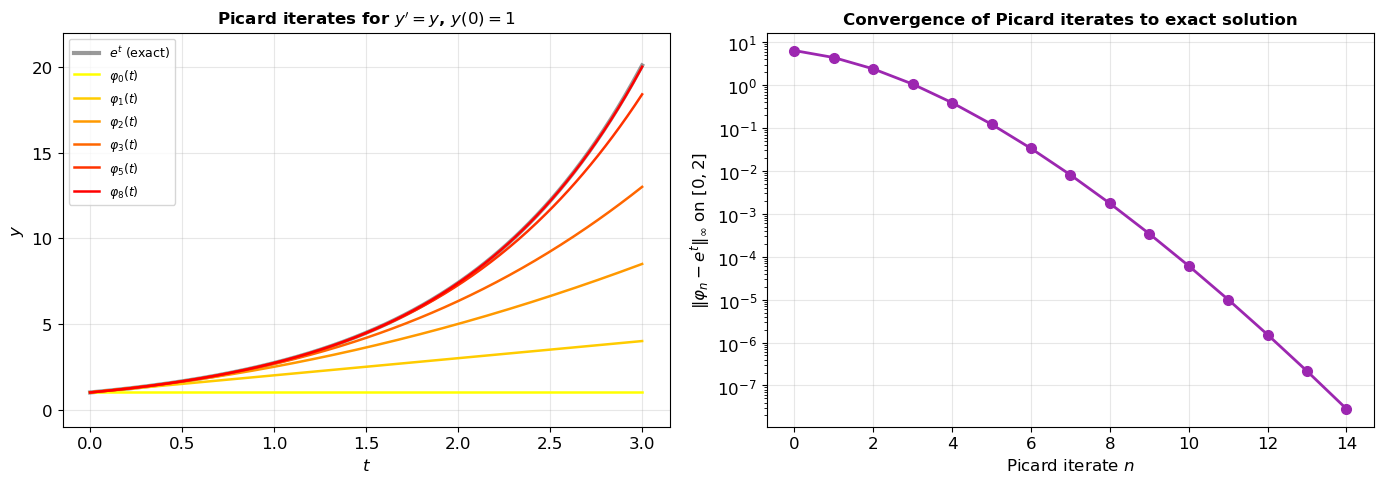

The Picard iterates phi_n(t) = sum_{k=0}^n t^k/k! are the partial sums
of the Taylor series of e^t, converging uniformly on compact intervals.

This is the Banach Fixed-Point Theorem in action on a function space!


In [18]:
import math
# ═══════════════════════════════════════════════════════════════════════════════
# 6.10  Picard iteration for y' = y, y(0) = 1  (exact solution: e^t)
# ═══════════════════════════════════════════════════════════════════════════════

# f(t, y) = y.  Picard iterates:
# phi_0(t) = 1
# phi_1(t) = 1 + int_0^t phi_0(s) ds = 1 + t
# phi_2(t) = 1 + int_0^t phi_1(s) ds = 1 + t + t^2/2
# phi_n(t) = sum_{k=0}^{n} t^k / k!   (partial sums of the Taylor series of e^t)

t_picard = np.linspace(0, 3, 300)

def picard_iterate_exp(t, n):
    """n-th Picard iterate for y'=y, y(0)=1: partial sum of e^t Taylor series."""
    result = np.zeros_like(t)
    for k in range(n + 1):
        result += t**k / math.factorial(k)
    return result


fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Left: successive Picard approximations
axes[0].plot(t_picard, np.exp(t_picard), 'k-', linewidth=3, label='$e^t$ (exact)', alpha=0.4)

picard_ns = [0, 1, 2, 3, 5, 8]
cmap4 = plt.cm.autumn_r
for i, n in enumerate(picard_ns):
    color = cmap4(i / (len(picard_ns) - 1))
    axes[0].plot(t_picard, picard_iterate_exp(t_picard, n),
                color=color, linewidth=1.8, label=f'$\\varphi_{{{n}}}(t)$')

axes[0].set_ylim(-1, 22)
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$y$')
axes[0].set_title("Picard iterates for $y' = y$, $y(0)=1$",
                   fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9, loc='upper left')

# Right: sup-norm error ||phi_n - e^t||_inf on [0, 2]
t_err = np.linspace(0, 2, 1000)
ns_err = np.arange(0, 15)
sup_errors = []
for n in ns_err:
    err = np.max(np.abs(picard_iterate_exp(t_err, n) - np.exp(t_err)))
    sup_errors.append(err)

axes[1].semilogy(ns_err, sup_errors, 'o-', color=COLORS['purple'], markersize=7)
axes[1].set_xlabel('Picard iterate $n$')
axes[1].set_ylabel('$\\|\\varphi_n - e^t\\|_\\infty$ on $[0,2]$')
axes[1].set_title('Convergence of Picard iterates to exact solution',
                   fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("The Picard iterates phi_n(t) = sum_{k=0}^n t^k/k! are the partial sums")
print("of the Taylor series of e^t, converging uniformly on compact intervals.")
print("\nThis is the Banach Fixed-Point Theorem in action on a function space!")

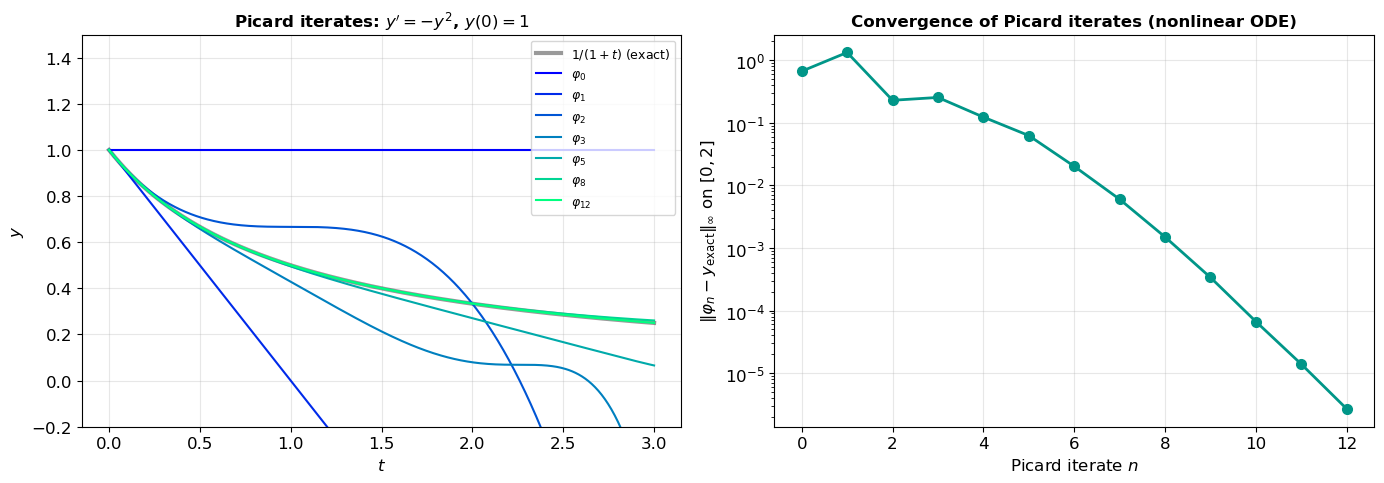

Even for the nonlinear ODE y' = -y^2, the Picard iterates converge
to the exact solution y(t) = 1/(1+t) on compact intervals.

The Picard-Lindelof theorem (powered by Banach's fixed-point theorem)
guarantees both EXISTENCE and UNIQUENESS of this solution.


In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# 6.11  Picard iteration for a nonlinear ODE: y' = -y^2, y(0) = 1
#       Exact solution: y(t) = 1/(1+t)
# ═══════════════════════════════════════════════════════════════════════════════

def picard_numerical(f, t0, y0, t_eval, n_iters):
    """
    Compute Picard iterates numerically using the trapezoidal rule.

    f : callable, f(t, y) -> dy/dt
    t0, y0 : initial condition
    t_eval : array of evaluation points
    n_iters : number of Picard iterations

    Returns: list of arrays, one per iteration.
    """
    dt = t_eval[1] - t_eval[0]
    # phi_0(t) = y0 (constant function)
    phi = np.full_like(t_eval, y0, dtype=float)
    all_iterates = [phi.copy()]

    for _ in range(n_iters):
        integrand = f(t_eval, phi)
        # Cumulative trapezoidal integration
        integral = np.zeros_like(t_eval)
        for j in range(1, len(t_eval)):
            integral[j] = integral[j-1] + 0.5 * dt * (integrand[j-1] + integrand[j])
        phi_new = y0 + integral
        phi = phi_new
        all_iterates.append(phi.copy())

    return all_iterates


# ODE: y' = -y^2, y(0) = 1.  Exact: y(t) = 1/(1+t).
f_nonlin = lambda t, y: -y**2
y_exact  = lambda t: 1.0 / (1.0 + t)

t_pic = np.linspace(0, 3, 500)
pic_iters = picard_numerical(f_nonlin, 0.0, 1.0, t_pic, n_iters=12)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Left: Picard approximations
axes[0].plot(t_pic, y_exact(t_pic), 'k-', linewidth=3, alpha=0.4, label='$1/(1+t)$ (exact)')

show_iters = [0, 1, 2, 3, 5, 8, 12]
cmap5 = plt.cm.winter
for i, idx in enumerate(show_iters):
    if idx < len(pic_iters):
        color = cmap5(i / (len(show_iters) - 1))
        axes[0].plot(t_pic, pic_iters[idx], color=color, linewidth=1.5,
                     label=f'$\\varphi_{{{idx}}}$')

axes[0].set_ylim(-0.2, 1.5)
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$y$')
axes[0].set_title("Picard iterates: $y' = -y^2$, $y(0)=1$",
                   fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9, loc='upper right')

# Right: convergence in sup-norm on [0, 2]
mask = t_pic <= 2.0
sup_errs_nonlin = []
for phi in pic_iters:
    err = np.max(np.abs(phi[mask] - y_exact(t_pic[mask])))
    sup_errs_nonlin.append(err)

axes[1].semilogy(range(len(sup_errs_nonlin)), sup_errs_nonlin, 'o-',
                 color=COLORS['teal'], markersize=7)
axes[1].set_xlabel('Picard iterate $n$')
axes[1].set_ylabel('$\\|\\varphi_n - y_{\\mathrm{exact}}\\|_\\infty$ on $[0,2]$')
axes[1].set_title('Convergence of Picard iterates (nonlinear ODE)',
                   fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Even for the nonlinear ODE y' = -y^2, the Picard iterates converge")
print("to the exact solution y(t) = 1/(1+t) on compact intervals.")
print("\nThe Picard-Lindelof theorem (powered by Banach's fixed-point theorem)")
print("guarantees both EXISTENCE and UNIQUENESS of this solution.")

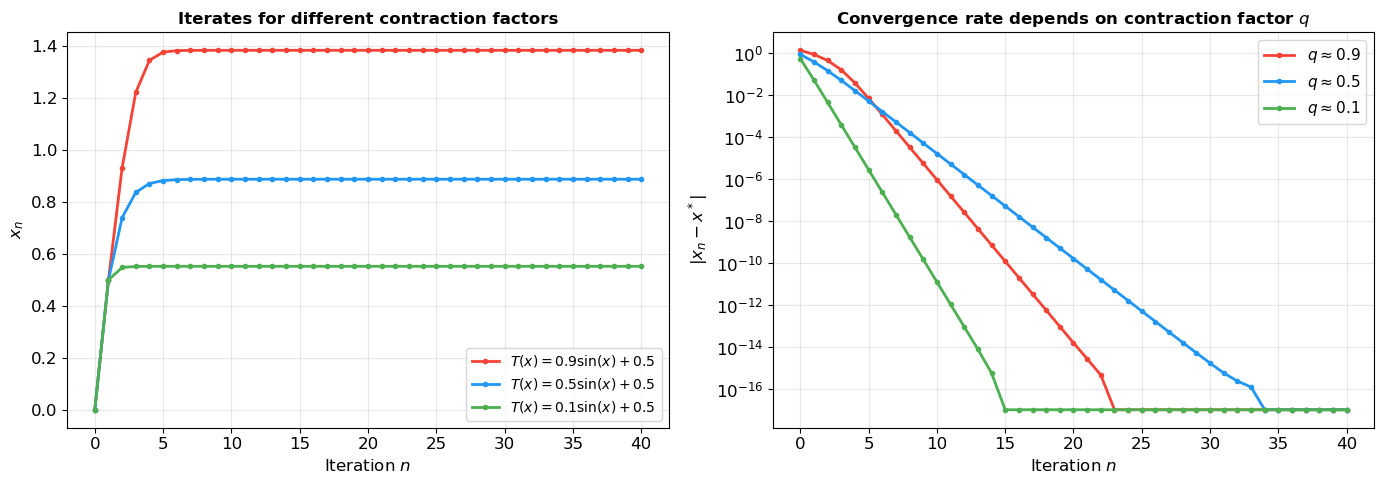

Smaller contraction factor q => faster geometric convergence.
The error decays as O(q^n), so halving q roughly doubles
the number of correct digits per iteration.


In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# 6.12  Comparing contraction factors and convergence speed
# ═══════════════════════════════════════════════════════════════════════════════

# Solve x = T(x) for several contractions with different factors q.
# T_a(x) = 0.9*sin(x) + 0.5   (q ~ 0.9, slow)
# T_b(x) = 0.5*sin(x) + 0.5   (q ~ 0.5, moderate)
# T_c(x) = 0.1*sin(x) + 0.5   (q ~ 0.1, fast)

contractions = [
    (lambda x: 0.9 * np.sin(x) + 0.5, 0.9, '$T(x)=0.9\\sin(x)+0.5$', COLORS['red']),
    (lambda x: 0.5 * np.sin(x) + 0.5, 0.5, '$T(x)=0.5\\sin(x)+0.5$', COLORS['blue']),
    (lambda x: 0.1 * np.sin(x) + 0.5, 0.1, '$T(x)=0.1\\sin(x)+0.5$', COLORS['green']),
]

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

for T_fn, q_val, label, color in contractions:
    x = 0.0
    iters_list = [x]
    for _ in range(40):
        x = T_fn(x)
        iters_list.append(x)
    iters_arr = np.array(iters_list)
    x_fix = iters_arr[-1]
    errs = np.abs(iters_arr - x_fix)

    axes[0].plot(iters_arr, '-o', color=color, markersize=3, label=label)
    axes[1].semilogy(range(len(errs)), errs + 1e-17, '-o', color=color,
                     markersize=3, label=f'$q \\approx {q_val}$')

axes[0].set_xlabel('Iteration $n$')
axes[0].set_ylabel('$x_n$')
axes[0].set_title('Iterates for different contraction factors',
                   fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

axes[1].set_xlabel('Iteration $n$')
axes[1].set_ylabel('$|x_n - x^*|$')
axes[1].set_title('Convergence rate depends on contraction factor $q$',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Smaller contraction factor q => faster geometric convergence.")
print("The error decays as O(q^n), so halving q roughly doubles")
print("the number of correct digits per iteration.")

---
## Summary

We have built the following conceptual hierarchy:

| Structure | Key property | Added ingredient |
|---|---|---|
| **Metric space** $(X, d)$ | Distance | Triangle inequality |
| **Normed space** $(V, \|\cdot\|)$ | Distance + linear structure | $d(x,y) = \|x-y\|$ |
| **Banach space** | Normed + complete | Every Cauchy sequence converges |

The major theorems of Banach space theory all exploit completeness:

- **Baire Category Theorem**: a complete metric space is not meagre (not a countable union of nowhere dense sets).
- **Open Mapping Theorem**: a bounded surjection between Banach spaces is an open map.
- **Closed Graph Theorem**: a linear map with a closed graph between Banach spaces is bounded.
- **Banach Fixed-Point Theorem**: a contraction on a complete metric space has a unique fixed point, found by iteration with geometric convergence.

These results are the foundation for the rest of functional analysis: operator theory, spectral theory, distribution theory, and PDE existence results all rest on this bedrock.

---
## References

1. **Kreyszig, E.** *Introductory Functional Analysis with Applications*. Wiley, 1978. (The classic beginner-friendly reference for metric, normed, and Banach spaces.)

2. **Rudin, W.** *Principles of Mathematical Analysis*, 3rd ed. McGraw-Hill, 1976. (Chapter 2: metric space topology; Chapter 7: sequences and series of functions; Chapter 9: contraction mapping theorem.)

3. **Brezis, H.** *Functional Analysis, Sobolev Spaces and Partial Differential Equations*. Springer, 2011. (Chapters 1--2 cover normed spaces, Banach spaces, and the Big Three theorems.)

4. **Conway, J.B.** *A Course in Functional Analysis*, 2nd ed. Springer, 1990. (Thorough treatment of Baire, Open Mapping, Closed Graph.)

5. **Teschl, G.** *Topics in Real and Functional Analysis*. Available online, University of Vienna. (Free, well-written notes covering all topics in this notebook.)

6. **Banach, S.** *Theorie des Operations Lineaires*. Monografje Matematyczne, Warsaw, 1932. (The original source of Banach space theory.)